In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
import cv2
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import Input
print('DONE')


DONE


In [2]:
import cv2
import os
import random
from tqdm import tqdm

# ── Output folders ──────────────────────────────────────────────
TRAIN_V   = "/kaggle/working/extracted_frames/train/violence"
TRAIN_NV  = "/kaggle/working/extracted_frames/train/nonviolence"
VAL_V     = "/kaggle/working/extracted_frames/val/violence"
VAL_NV    = "/kaggle/working/extracted_frames/val/nonviolence"

for folder in [TRAIN_V, TRAIN_NV, VAL_V, VAL_NV]:
    os.makedirs(folder, exist_ok=True)

# ── Extract frames from one video ───────────────────────────────
def extract_frames(video_path, out_folder, fps=3):
    cap = cv2.VideoCapture(video_path)
    interval = int(cap.get(cv2.CAP_PROP_FPS) / fps)
    name = os.path.splitext(os.path.basename(video_path))[0]
    i = saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if i % interval == 0:
            cv2.imwrite(f"{out_folder}/{name}_frame{saved}.jpg", frame)
            saved += 1
        i += 1
    cap.release()

# ── Process a folder of videos ──────────────────────────────────
def process(folder, train_out, val_out, val_split=0.2):
    videos = [f for f in os.listdir(folder) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    random.shuffle(videos)

    split = int(len(videos) * val_split)
    val_videos, train_videos = videos[:split], videos[split:]

    for v in tqdm(val_videos,   desc="Val"):
        extract_frames(f"{folder}/{v}", val_out)
    for v in tqdm(train_videos, desc="Train"):
        extract_frames(f"{folder}/{v}", train_out)

# ── Run ─────────────────────────────────────────────────────────
RLVD = "/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset"
RWF  = "/kaggle/input/rwf2000/RWF-2000/train"

process(f"{RLVD}/Violence",    TRAIN_V,  VAL_V)
process(f"{RLVD}/NonViolence", TRAIN_NV, VAL_NV)
process(f"{RWF}/Fight",        TRAIN_V,  VAL_V)
process(f"{RWF}/NonFight",     TRAIN_NV, VAL_NV)

print("Done!")

Train:  28%|██▊       | 228/800 [00:20<00:52, 10.94it/s][h264 @ 0x5a26054b6cc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x5a26054b6cc0] error while decoding MB 98 31
Train: 100%|██████████| 640/640 [02:27<00:00,  4.33it/s]

Done!


In [3]:
import os

# Specify the path to the main directory
main_dir = '/kaggle/working/extracted_frames'

# Dictionary to store file counts
file_counts = {}

# Walk through each subdirectory and count files
for root, dirs, files in os.walk(main_dir):
    # Only count files, skip directories
    file_counts[root] = len(files)

# Print the file counts in each folder
for folder, count in file_counts.items():
    print(f"{folder}: {count} files")


/kaggle/working/extracted_frames: 0 files
/kaggle/working/extracted_frames/train: 0 files
/kaggle/working/extracted_frames/train/violence: 23396 files
/kaggle/working/extracted_frames/train/nonviolence: 23078 files
/kaggle/working/extracted_frames/val: 0 files
/kaggle/working/extracted_frames/val/violence: 5931 files
/kaggle/working/extracted_frames/val/nonviolence: 5708 files


In [4]:
# Paths to augmented frames for training and validation
train_dir = '/kaggle/working/extracted_frames/train'
val_dir = '/kaggle/working/extracted_frames/val'
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


"""
   ,
    rotation_range=5,              # Small rotation, up to 5 degrees
    width_shift_range=0.05,        # Small horizontal shift, up to 5% of width
    height_shift_range=0.05,       # Small vertical shift, up to 5% of height
    zoom_range=0.1,                # Slight zoom variation, up to 10%
    fill_mode='nearest' 
    """
# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'  
)


val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle= True ,
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

Found 46474 images belonging to 2 classes.
Found 11639 images belonging to 2 classes.


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Define the MobileNetV3Small model
input_tensor = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model = MobileNetV3Small(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')



base_model.trainable = True  # Initially freeze the entire base model
"""# Unfreeze the top 10 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True
    , kernel_regularizer=l2(0.01)
"""
    

# Add custom layers on top of MobileNetV3Small
x = base_model(input_tensor)
x = GlobalAveragePooling2D()(x)

x = Dense(1024)(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)  # Dropout

x = Dense(512)(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)  # Dropout

output = Dense(1, activation='sigmoid')(x)

# Build the model
model = models.Model(inputs=input_tensor, outputs=output)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobilenetV3small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,055,281 (7.84 MB)

 Trainable params: 2,043,169 (7.79 MB)

 Non-trainable params: 12,112 (47.31 KB)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint 

model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks for adaptive learning rate and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)  
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',       
    save_best_only=True,     
    mode='min',               
    verbose=1                 
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint,reduce_lr]
)

Epoch 1/30


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1773229906.761227    8116 service.cc:145] XLA service 0x7f18b4004090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773229906.761283    8116 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773229906.761289    8116 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/2905 ━━━━━━━━━━━━━━━━━━━━ 54:13:56 67s/step - accuracy: 0.5000 - loss: 0.9028

I0000 00:00:1773229954.013892    8116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7349 - loss: 0.5051
Epoch 1: val_loss improved from inf to 1.16606, saving model to best_model.keras
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 749s 235ms/step - accuracy: 0.7349 - loss: 0.5050 - val_accuracy: 0.4904 - val_loss: 1.1661 - learning_rate: 1.0000e-04
Epoch 2/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8829 - loss: 0.2713
Epoch 2: val_loss did not improve from 1.16606
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 653s 224ms/step - accuracy: 0.8829 - loss: 0.2712 - val_accuracy: 0.5103 - val_loss: 1.6002 - learning_rate: 1.0000e-04
Epoch 3/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9194 - loss: 0.1957
Epoch 3: val_loss did not improve from 1.16606
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 690s 237ms/step - accuracy: 0.9194 - loss: 0.1957 - val_accuracy: 0.5055 - val_loss: 3.5411 - learning_rate: 1.0000e-04
Epoch 4/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9354 - loss: 0.1543
Epoch 4: val_loss impro

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9906 - loss: 0.0248
Epoch 21: val_loss did not improve from 0.62781
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 702s 241ms/step - accuracy: 0.9906 - loss: 0.0248 - val_accuracy: 0.8718 - val_loss: 0.6681 - learning_rate: 2.5000e-05
Epoch 22/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9916 - loss: 0.0223
Epoch 22: val_loss did not improve from 0.62781
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 702s 241ms/step - accuracy: 0.9916 - loss: 0.0223 - val_accuracy: 0.8885 - val_loss: 0.7150 - learning_rate: 1.2500e-05
Epoch 23/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9924 - loss: 0.0201
Epoch 23: val_loss did not improve from 0.62781
2905/2905 ━━━━━━━━━━━━━━━━━━━━ 693s 238ms/step - accuracy: 0.9924 - loss: 0.0201 - val_accuracy: 0.8850 - val_loss: 0.8015 - learning_rate: 1.2500e-05
Epoch 24/30
2904/2905 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9922 - loss: 0.0209
Epoch 24: val_loss did not improve from 0.62781
290

In [7]:
from sklearn.metrics import classification_report
import numpy as np

# Step 1: Evaluate the model using the validation generator
loss, accuracy = model.evaluate(val_generator, verbose=1)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

# Step 2: Generate predictions
predictions = model.predict(val_generator, verbose=1)          
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)  # Binary classification: Threshold at 0.5

# Step 3: Get true labels from the generator
true_classes = val_generator.classes  # Assuming this provides the true labels for each sample
class_labels = ['Class 0', 'Class 1']  # Replace with actual class names if available

# Step 4: Generate classification report
print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


728/728 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.8898 - loss: 0.6143
Validation Loss: 0.8303784132003784
Validation Accuracy: 0.8526505827903748
728/728 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.81      0.91      0.86      5708
     Class 1       0.90      0.79      0.85      5931

    accuracy                           0.85     11639
   macro avg       0.86      0.85      0.85     11639
weighted avg       0.86      0.85      0.85     11639



Confusion Matrix:
[[5212  496]
 [1219 4712]]


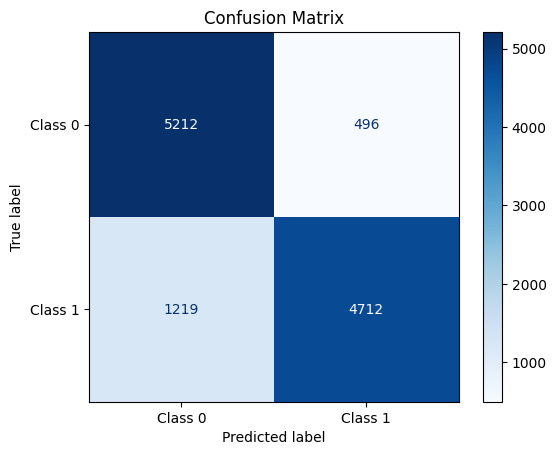

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

# Step 2: Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Save the model in .keras format
model.save("movileV3_89.keras")
